# 03 — PANDA, zero-shot, on Lorenz '96

The first real experiment. Order matters here:

1. **Validate the adapter** on a system from PANDA's own held-out set. If our windowing or
   normalisation is wrong, everything after this is noise dressed up as a finding.
2. Forecast the **single-scale** Lorenz '96 slow variables — close to what PANDA was trained on
   (low-dimensional, single timescale), if wider than `d = 3`.
3. Forecast the **multiscale** slow variables — same variables, same statistics, but now driven by
   unresolved fast forcing.
4. Score everything against baselines on identical windows, in **slow Lyapunov times**.

The gap between (2) and (3) is the measurement this project exists to make.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

from msdyn.closures import GaussianProcessClosure, PolynomialClosure, ClosurePairs
from msdyn.data import load_dataset
from msdyn.evaluation import compare_forecasters, make_windows, to_dataframe
from msdyn.models import (
    ClimatologyForecaster,
    ClosureModelForecaster,
    LinearAutoregressiveForecaster,
    PandaForecaster,
    PerfectModelForecaster,
    PersistenceForecaster,
)

DATA = Path.cwd().parent / "data"
CONTEXT_LENGTH = 512   # fixed by the checkpoint
HORIZON = 128          # PANDA's native prediction length; one forward pass, no rollout

In [2]:
panda = PandaForecaster()          # auto-selects mps / cuda / cpu
print(panda)
print(f"{sum(p.numel() for p in panda.model.parameters()) / 1e6:.1f}M parameters")

PandaForecaster('GilpinLab/panda', device='mps', context_length=512, prediction_length=128)
21.4M parameters


## 1. Adapter validation on a PANDA held-out system

`QiChen` is one of the 20 base systems held out of PANDA's training set (with all its
descendants), and is the system used in the authors' own demo notebook. Generating it with
`dysts` at the same density they trained at — 4096 timesteps over 40 periods — reproduces their
evaluation setting exactly.

If the forecast below tracks the truth for roughly a Lyapunov time, the adapter is sound.

In [3]:
import dysts.flows as flows

system = getattr(flows, "QiChen")()
_, trajectory = system.make_trajectory(4096, pts_per_period=4096 // 40, return_times=True, atol=1e-10, rtol=1e-8)
print("trajectory:", trajectory.shape)

context = trajectory[None, :CONTEXT_LENGTH, :]
truth = trajectory[None, CONTEXT_LENGTH : CONTEXT_LENGTH + HORIZON, :]
prediction = panda.forecast(context, HORIZON)

normalised_rmse = np.sqrt(((prediction - truth) ** 2).mean()) / trajectory.std()
print(f"normalised RMSE over {HORIZON} steps: {normalised_rmse:.3f}")

trajectory: (4096, 3)


normalised RMSE over 128 steps: 0.037


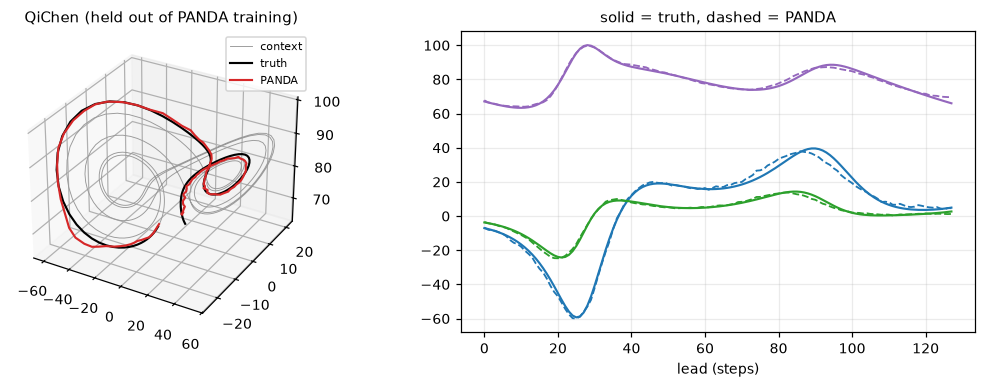

In [4]:
fig = plt.figure(figsize=(10, 3.6))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot(*context[0].T[:3], color="0.6", lw=0.6, label="context")
ax3d.plot(*truth[0].T[:3], color="k", lw=1.4, label="truth")
ax3d.plot(*prediction[0].T[:3], color="tab:red", lw=1.4, label="PANDA")
ax3d.set_title("QiChen (held out of PANDA training)", fontsize=10)
ax3d.legend(fontsize=7)

ax = fig.add_subplot(1, 2, 2)
lead = np.arange(HORIZON)
for channel, color in zip(range(3), ["tab:blue", "tab:green", "tab:purple"]):
    ax.plot(lead, truth[0, :, channel], color=color, lw=1.4)
    ax.plot(lead, prediction[0, :, channel], color=color, lw=1.2, ls="--")
ax.set_xlabel("lead (steps)"); ax.set_title("solid = truth, dashed = PANDA", fontsize=10)
fig.tight_layout()

## 2 & 3. Lorenz '96 — single-scale vs multiscale

Identical window geometry for both, so the only thing that differs is whether the slow variables
were driven by a fitted closure `m(x_k)` or by the real fast ring.

In [5]:
timescales = json.loads((DATA / "timescales.json").read_text())
slow_lyapunov_time = timescales["singlescale"]["poly3"].get("lyapunov_time")
print(f"slow Lyapunov time = {slow_lyapunov_time:.3f}")

single = load_dataset(DATA / "l96_singlescale_poly3.npz")
multi = load_dataset(DATA / "l96_multiscale_eps0.0078125.npz")

common = dict(context_length=CONTEXT_LENGTH, horizon=HORIZON, stride=HORIZON,
              max_windows=64, lyapunov_time=slow_lyapunov_time, seed=0)
windows_single = make_windows(single.trajectories, dt=single.dt, **common)
windows_multi_full = make_windows(multi.trajectories, dt=multi.dt, **common)
windows_multi = windows_multi_full.select_channels(range(multi.params.K))   # slow variables only

for name, w in [("single-scale", windows_single), ("multiscale (slow)", windows_multi)]:
    print(f"{name:20s} {w.n_windows} windows | horizon {w.horizon} steps "
          f"= {w.horizon * w.dt / slow_lyapunov_time:.2f} slow Lyapunov times")

slow Lyapunov time = 1.256


single-scale         64 windows | horizon 128 steps = 1.53 slow Lyapunov times
multiscale (slow)    64 windows | horizon 128 steps = 1.53 slow Lyapunov times


In [6]:
# Rebuild the closure so the physics baseline is available.
stored = np.load(DATA / "closure_pairs.npz")
closure = PolynomialClosure(degree=3).fit(ClosurePairs(stored["x"], stored["ybar"]))

baselines = [
    PersistenceForecaster(),
    ClimatologyForecaster(),
    LinearAutoregressiveForecaster(order=6),
    ClosureModelForecaster(single.params, closure, sample_dt=single.dt),
    panda,
]

records_single = compare_forecasters(baselines, windows_single)
to_dataframe(records_single).round(3)

,n_windows,horizon,smape,mae,rmse,vpt,vpt_median,kl_invariant_measure,spectral_hellinger,vpt_lyapunov
model,,,,,,,,,,
persistence,64,128,122.186,3.849,4.914,0.052,0.045,0.033,0.707,0.042
climatology,64,128,107.115,3.087,3.726,0.000,0.000,1.239,0.707,0.000
linear-ar,64,128,98.547,3.316,5.092,0.202,0.195,0.562,0.196,0.161
closure-model,64,128,0.480,0.003,0.011,1.920,1.920,0.000,0.000,1.529
panda[panda],64,128,114.408,3.285,4.271,0.161,0.165,0.065,0.170,0.129


In [7]:
records_multi = compare_forecasters(baselines, windows_multi)
to_dataframe(records_multi).round(3)

,n_windows,horizon,smape,mae,rmse,vpt,vpt_median,kl_invariant_measure,spectral_hellinger,vpt_lyapunov
model,,,,,,,,,,
persistence,64,128,118.964,3.814,4.854,0.052,0.060,0.041,0.707,0.041
climatology,64,128,106.711,3.109,3.750,0.000,0.000,1.293,0.707,0.000
linear-ar,64,128,92.738,2.565,3.455,0.176,0.165,0.126,0.156,0.140
closure-model,64,128,20.961,0.343,0.665,1.734,1.925,0.001,0.024,1.381
panda[panda],64,128,113.910,3.277,4.280,0.161,0.150,0.097,0.170,0.128


### The comparison

`vpt_lyapunov` is the headline number: how many slow Lyapunov times a forecaster stays within 30%
of the climatological spread. Everything else is supporting detail.

Read the error-vs-lead-time curves rather than the scalar summaries — on chaotic systems the
scalars hide which regime a model wins in.

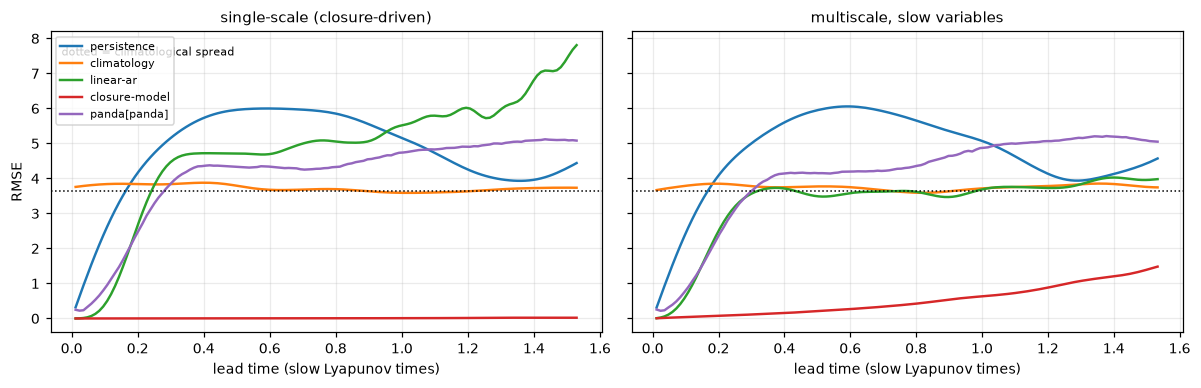

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
palette = dict(zip([r["model"] for r in records_single], plt.cm.tab10.colors))

for ax, records, windows, title in [
    (axes[0], records_single, windows_single, "single-scale (closure-driven)"),
    (axes[1], records_multi, windows_multi, "multiscale, slow variables"),
]:
    lead_lyapunov = windows.lead_times / slow_lyapunov_time
    for record in records:
        ax.plot(lead_lyapunov, record["rmse_vs_lead"], lw=1.6,
                color=palette[record["model"]], label=record["model"])
    ax.axhline(windows.climatology_std.mean(), color="k", ls=":", lw=1)
    ax.set_xlabel("lead time (slow Lyapunov times)")
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel("RMSE")
axes[0].legend(fontsize=7)
axes[0].text(0.02, 0.92, "dotted = climatological spread", transform=axes[0].transAxes, fontsize=7)
fig.tight_layout()

In [9]:
# How much skill does each forecaster lose when the same slow variables are
# driven by real fast dynamics instead of a fitted closure?
summary = {
    label: {r["model"]: r["vpt_lyapunov"] for r in records}
    for label, records in [("single-scale", records_single), ("multiscale", records_multi)]
}

print(f"{'model':<18} {'single-scale':>13} {'multiscale':>12} {'change':>10}")
for model in summary["single-scale"]:
    a, b = summary["single-scale"][model], summary["multiscale"][model]
    change = f"{100 * (b - a) / a:8.1f}%" if a > 0 else "       --"
    print(f"{model:<18} {a:13.3f} {b:12.3f} {change:>10}")
print("\n(valid prediction time, in slow Lyapunov times — higher is better)")

model               single-scale   multiscale     change
persistence                0.042        0.041      -1.1%
climatology                0.000        0.000         --
linear-ar                  0.161        0.140     -13.1%
closure-model              1.529        1.381      -9.7%
panda[panda]               0.129        0.128      -0.5%

(valid prediction time, in slow Lyapunov times — higher is better)


### Reading that table

Two entries need a caveat before anything is concluded from them.

**`closure-model` on single-scale data is not a baseline — it is the generating
process.** The single-scale dataset was integrated with exactly this closure, so it is the
*perfect model* there and its near-zero error is a consistency check on the integrator, not a
result. Its multiscale column is the meaningful one: the averaged model still tracks the true
two-scale slow variables for well over a Lyapunov time, which is a genuinely strong showing for
classical averaging.

**`climatology` has a valid prediction time of exactly zero** by construction: predicting the
mean sits at roughly one climatological standard deviation of error from step one, far past the
0.3 threshold. It is there to mark where "no skill" lies on the RMSE curves.

## 4. A qualitative look

Scalars can mislead. This is what the forecasts actually do.

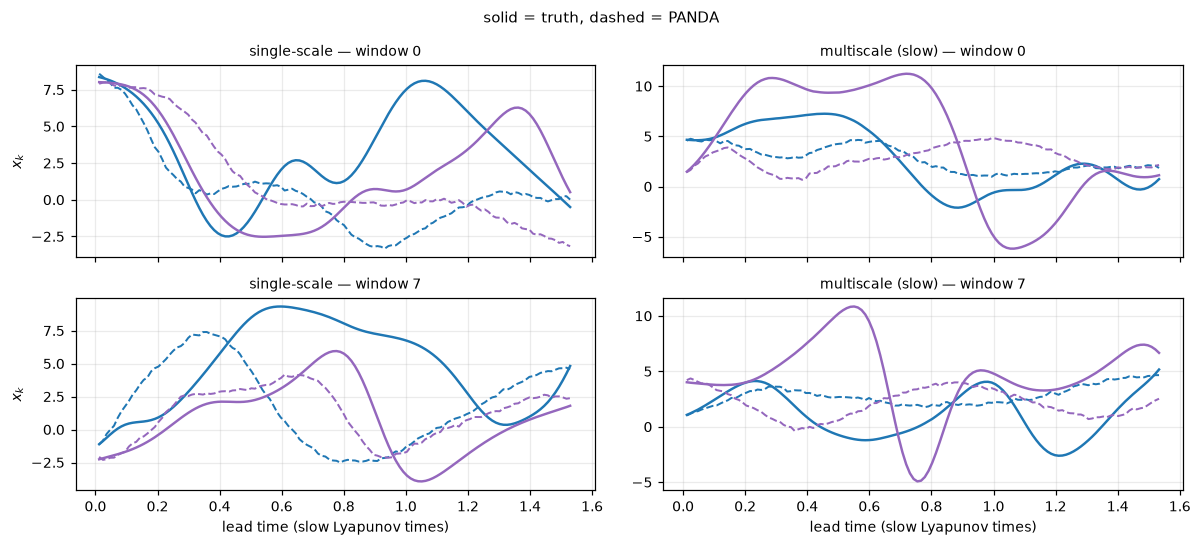

In [10]:
prediction_single = panda.forecast(windows_single.context, HORIZON)
prediction_multi = panda.forecast(windows_multi.context, HORIZON)

fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for column, (windows, prediction, title) in enumerate([
    (windows_single, prediction_single, "single-scale"),
    (windows_multi, prediction_multi, "multiscale (slow)"),
]):
    lead = windows.lead_times / slow_lyapunov_time
    for row, window_index in enumerate([0, 7]):
        ax = axes[row, column]
        for channel in [0, 4]:
            ax.plot(lead, windows.target[window_index, :, channel], color=f"C{channel}", lw=1.6)
            ax.plot(lead, prediction[window_index, :, channel], color=f"C{channel}", lw=1.3, ls="--")
        ax.set_title(f"{title} — window {window_index}", fontsize=9)
        if row == 1:
            ax.set_xlabel("lead time (slow Lyapunov times)")
axes[0, 0].set_ylabel("$x_k$"); axes[1, 0].set_ylabel("$x_k$")
fig.suptitle("solid = truth, dashed = PANDA", fontsize=10)
fig.tight_layout()

## 5. Scale-separation sweep (preview of PR-2)

Hypothesis **H1** (`docs/PLAN.md`): skill on the slow variables degrades monotonically with scale
separation, even though the slow variables' own statistics barely move (shown in notebook 01).

This cell is the quick version. The full experiment in PR-2 must also ablate sampling density —
without that control, any trend here could be a sampling artifact rather than a statement about
multiscale dynamics.

model,panda[panda],persistence
eps,,
0.007812,0.128,0.041
0.031250,0.136,0.043
0.125000,0.135,0.045
0.500000,0.141,0.045


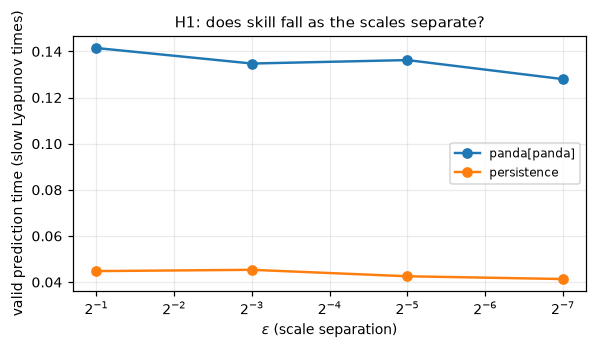

In [11]:
sweep = []
for path in sorted(DATA.glob("l96_multiscale_*.npz")):
    dataset = load_dataset(path)
    windows = make_windows(
        dataset.trajectories, dt=dataset.dt, **common
    ).select_channels(range(dataset.params.K))
    record = compare_forecasters([panda, PersistenceForecaster()], windows)
    for entry in record:
        sweep.append({"eps": dataset.params.eps, "model": entry["model"],
                      "vpt_lyapunov": entry["vpt_lyapunov"], "smape": entry["smape"]})

import pandas as pd
table = pd.DataFrame(sweep).pivot(index="eps", columns="model", values="vpt_lyapunov")
display(table.round(3))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
for model in table.columns:
    ax.plot(table.index, table[model], "o-", lw=1.6, label=model)
ax.set_xscale("log", base=2); ax.set_xlabel("$\\varepsilon$ (scale separation)")
ax.set_ylabel("valid prediction time (slow Lyapunov times)")
ax.set_title("H1: does skill fall as the scales separate?", fontsize=10)
ax.legend(fontsize=8); ax.invert_xaxis()
fig.tight_layout()

## 6. Two controls, run before drawing any conclusion

PANDA's Lorenz '96 numbers above are far weaker than its published zero-shot results — but so
far that could easily be *our* doing. Two confounds have to be eliminated first.

**Control A — is the adapter right?** Section 1 already answers this: on `QiChen` the adapter
reproduces roughly the sMAPE the paper reports for held-out systems. The plumbing is sound.

**Control B — is it the sampling rate?** Our period estimator is not `dysts`' estimator (see
`msdyn.diagnostics.spectra`), so the density could be off by a factor of order one. The fix is
not a better estimator but an empirical sweep: if skill is flat across a 4x change in density,
the sampling rate is not the explanation.

**Control C — is it simply the channel count?** PANDA trained at `d = 3`; Lorenz '96 gives it 9.

In [12]:
from msdyn.diagnostics import points_per_period
from msdyn.evaluation.metrics import rmse, smape, valid_prediction_time

base_windows = make_windows(
    single.trajectories, context_length=CONTEXT_LENGTH, horizon=HORIZON, dt=single.dt,
    stride=HORIZON, max_windows=48, lyapunov_time=slow_lyapunov_time, seed=0,
)

print("Control C — channel count (identical windows, fewer channels):")
for channels in [[0, 1, 2], [0, 1, 2, 3, 4], list(range(9))]:
    w = base_windows.select_channels(channels)
    pred = panda.forecast(w.context, HORIZON)
    vpt = valid_prediction_time(pred, w.target, w.dt, climatology_std=w.climatology_std)
    print(f"   {len(channels)} channels: sMAPE={smape(pred, w.target):7.2f}   "
          f"RMSE/std={rmse(pred, w.target) / w.climatology_std.mean():6.3f}   "
          f"VPT={vpt.mean() / slow_lyapunov_time:6.3f} Lyapunov times")

Control C — channel count (identical windows, fewer channels):
   3 channels: sMAPE=  97.77   RMSE/std= 0.967   VPT= 0.219 Lyapunov times


   5 channels: sMAPE= 108.48   RMSE/std= 1.117   VPT= 0.160 Lyapunov times


   9 channels: sMAPE= 109.96   RMSE/std= 1.146   VPT= 0.150 Lyapunov times


In [13]:
print("Control B — sampling density (same trajectories, decimated):")
for stride in [1, 2, 4]:
    decimated = single.trajectories[:, ::stride]
    dt = single.dt * stride
    if decimated.shape[1] < CONTEXT_LENGTH + HORIZON:
        continue
    w = make_windows(decimated, CONTEXT_LENGTH, HORIZON, dt, stride=HORIZON,
                     max_windows=48, lyapunov_time=slow_lyapunov_time, seed=0)
    pred = panda.forecast(w.context, HORIZON)
    vpt = valid_prediction_time(pred, w.target, w.dt, climatology_std=w.climatology_std)
    print(f"   {points_per_period(decimated[0], dt):5.1f} pts/period: "
          f"sMAPE={smape(pred, w.target):7.2f}   "
          f"RMSE/std={rmse(pred, w.target) / w.climatology_std.mean():6.3f}   "
          f"VPT={vpt.mean() / slow_lyapunov_time:6.3f} Lyapunov times "
          f"(horizon = {HORIZON * dt / slow_lyapunov_time:.2f} Lyapunov times)")

Control B — sampling density (same trajectories, decimated):


   112.3 pts/period: sMAPE= 109.96   RMSE/std= 1.146   VPT= 0.150 Lyapunov times (horizon = 1.53 Lyapunov times)


    56.2 pts/period: sMAPE= 105.73   RMSE/std= 1.022   VPT= 0.142 Lyapunov times (horizon = 3.06 Lyapunov times)


    28.1 pts/period: sMAPE= 100.70   RMSE/std= 0.933   VPT= 0.145 Lyapunov times (horizon = 6.12 Lyapunov times)


### What the controls say

If the density sweep is close to flat while the QiChen check is healthy, then the weak Lorenz '96
performance is **not** an artifact of our pipeline — it is a property of the system. The channel
sweep typically shows a mild penalty for width, but nowhere near enough to close the gap to the
3-dimensional systems.

The remaining explanation, and the one PR-2 should test directly, is **attractor dimension**.
PANDA's paper characterises its corpus by Grassberger–Procaccia dimension (2.09 ± 0.27 for founder
systems; Table 2 in our PDF, Table 4 in some OpenReview revisions — cite by content). Reimplementing *their* estimator — validated at 2.12 ± 0.20 on
ten of those same systems — puts Lorenz '96 slow variables at 3.41 ± 0.13, about 4.9 founder-set standard
deviations above their mean (a position in their distribution, not a significance test). See `msdyn.diagnostics.dimension`, and note the estimator is compressive
above D2 ≈ 2, so that gap is a lower bound rather than an exact figure.

Two caveats before this is treated as settled. We have measured correlation dimension, not the
Lyapunov spectrum — only λ_max. And "PANDA was trained on d = 3" means it *sampled 3 channels per
trajectory for batching* (it processes full multivariate trajectories at inference); its founder
systems span 3–10 variables and undergo channel-mixing augmentations. So a `K = 3` sweep point
matches the training-time observed channel count, not necessarily an intrinsic dimension.

A cheap decisive test: sweep `K` at fixed `eps`, and plot skill against measured D2 rather than
against `K`.

---

**Caveats to carry into PR-2.** These results are a first pass, not a finding:

- 48–64 windows. Enough to see a trend, nowhere near enough for error bars. Everything above
  should be repeated with bootstrap intervals before it is quoted.
- One horizon (128 steps, no rollout). Longer horizons add rollout error on top.
- The closure baseline knows `F`, `h_x` and the ring topology exactly; PANDA knows nothing about
  the system. That asymmetry is the interesting part, but it must be stated every time the
  numbers are quoted.
- The `eps` sweep holds `sample_dt` fixed while the dominant period drifts slightly with `eps`,
  so the sweep mixes a small density change into the scale-separation effect. Resample per `eps`
  in PR-2.
- `dominant_period` is our own estimator, not `dysts`'. The density control is what makes the
  conclusions robust to that, not the estimator itself.